# GLD Implied Volatility Surface: Black-Scholes Failure Diagnostic

**Data:** Gold Spot ETF (GLD) options from Barchart.com, trading date 2025-07-18.
**Maturities:** 11 expirations from ~8 DTE to ~127 DTE.
**Objective:** Compute Black-Scholes implied volatilities from market mid-prices, identify where the flat-vol assumption fails, and establish the benchmark dataset for all subsequent models (Heston, NIG, BGM, ConvLSTM).

---

In [1]:
import sys
import os
from pathlib import Path

# Robust project root detection: notebook is in notebooks/, go up one level
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

import warnings
warnings.filterwarnings('ignore')

from volsurf.pricing import black_scholes as bs

%load_ext autoreload
%autoreload 2

print("\nImports OK — autoreload enabled")

Project root: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit
Data dir:     c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\data
Output dir:   c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output

Imports OK — autoreload enabled


## Section A: Load GLD Option Data

Your preprocessed CSV from the Commodity Options project.

In [2]:
# ============================================================
# GLD PARAMETERS — 2025-07-18
# ============================================================
import yfinance as yf

TRADE_DATE = "2025-07-18"
#GLD_SPOT = 307.59

## Gold Spot ETF Data : We shall use as S0
GLD_SPOT = yf.download(tickers = 'GLD', start = '2025-07-18', end = '2025-07-19', auto_adjust = True, progress = False)['Close']
GLD_SPOT = GLD_SPOT.loc[TRADE_DATE, 'GLD']
print(f"Gold Spot price is ${GLD_SPOT: .4f}")
DIVIDEND_YIELD = 0.004            # GLD expense ratio (not a dividend; models ETF decay)

CSV_PATH = r"C:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\data\true_gold_spot_data.csv"

df = pd.read_csv(CSV_PATH)

# Drop stray index columns
for col in ["Unnamed: 0", "Index", "index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Clean IV if stored as string with %
if df["IV"].dtype == object:
    df["IV"] = df["IV"].str.rstrip("%").astype(float) / 100

# Standardise column names
df = df.rename(columns={
    "Tau": "T",
    "Mid": "midPrice",
    "Type": "option_type",
    "Strike": "strike",
    "Maturity": "expiration_date",
})
df["option_type"] = df["option_type"].str.lower()

# Parse dates
df["expiration_date"] = pd.to_datetime(df["expiration_date"]).dt.date
df["observation_date"] = pd.to_datetime(TRADE_DATE).date()

# Compute days to expiry if not present
if "days_to_expiry" not in df.columns:
    df["days_to_expiry"] = (pd.to_datetime(df["expiration_date"]) - pd.to_datetime(TRADE_DATE)).dt.days

df["T"] = df["days_to_expiry"] / 365.0
df["spot"] = GLD_SPOT
df["moneyness"] = df["strike"] / GLD_SPOT
df["dividend_yield"] = DIVIDEND_YIELD

# Sanity filter
df = df[(df["midPrice"] > 0.01) & (df["days_to_expiry"] > 0)].copy()

print(f"Loaded GLD options: {len(df)} quotes")
print(f"  Spot:        ${GLD_SPOT:.2f}")
print(f"  Maturities:  {df['expiration_date'].nunique()}")
print(f"  DTE range:   {df['days_to_expiry'].min()} - {df['days_to_expiry'].max()}")
print(f"  Strikes:     {df['strike'].nunique()}")
print(f"  Calls:       {len(df[df['option_type']=='call'])}")
print(f"  Puts:        {len(df[df['option_type']=='put'])}")
print(f"  Barchart IV: {df['IV'].min():.2%} - {df['IV'].max():.2%}")
print(f"\nMaturity breakdown:")
print(df.groupby("expiration_date").size())

Gold Spot price is $ 308.3900
Loaded GLD options: 880 quotes
  Spot:        $308.39
  Maturities:  11
  DTE range:   7 - 126
  Strikes:     47
  Calls:       440
  Puts:        440
  Barchart IV: 11.28% - 31.41%

Maturity breakdown:
expiration_date
2025-07-25    80
2025-07-28    80
2025-07-30    80
2025-08-08    80
2025-08-15    80
2025-08-22    80
2025-08-29    80
2025-09-19    80
2025-09-30    80
2025-10-17    80
2025-11-21    80
dtype: int64


## Section B: Risk-Free Rate via Treasury Yield Curve

Interpolate US Treasury yields to obtain a maturity-specific risk-free rate.

In [4]:
try:
    import requests
    url = ("https://home.treasury.gov/resource-center/data-chart-center/"
           "interest-rates/daily-treasury-rates.csv/2025/all?"
           "type=daily_treasury_yield_curve&field_tdr_date_value=2025&page&_format=csv")
    r = requests.get(url, timeout=15)
    if r.status_code == 200:
        Path("data").mkdir(parents=True, exist_ok=True)
        with open("data/treasury_2025.csv", "wb") as f:
            f.write(r.content)
        ty = pd.read_csv("data/treasury_2025.csv")
        ty["Date"] = pd.to_datetime(ty["Date"])
        target = ty[ty["Date"] == pd.Timestamp(TRADE_DATE)]
        if target.empty:
            target = ty[ty["Date"] == pd.Timestamp("2025-07-18")]
        if not target.empty:
            mat_map = {
                "1 Mo": 1/12, "2 Mo": 2/12, "3 Mo": 3/12, "4 Mo": 4/12,
                "6 Mo": 6/12, "1 Yr": 1.0, "2 Yr": 2.0, "3 Yr": 3.0,
                "5 Yr": 5.0, "7 Yr": 7.0, "10 Yr": 10.0, "20 Yr": 20.0, "30 Yr": 30.0
            }
            yields, mats = [], []
            for col, yrs in mat_map.items():
                if col in target.columns and pd.notna(target[col].values[0]):
                    mats.append(yrs)
                    yields.append(target[col].values[0] / 100)
            if len(mats) >= 5:
                yield_maturities = np.array(mats)
                yield_data = np.array(yields)
                print(f"Using downloaded Treasury yields for {target['Date'].values[0]}")
            else:
                raise ValueError("Too few Treasury columns")
        else:
            raise ValueError("Date not found")
    else:
        raise ValueError(f"HTTP {r.status_code}")
except Exception as e:
    print(f"Download failed ({e}). Using hardcoded yields.")
    yield_maturities = np.array([1/12, 1.5/12, 2/12, 3/12, 4/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
    yield_data = np.array([4.35, 4.39, 4.46, 4.40, 4.42, 4.30, 4.08, 3.88, 3.84, 3.96, 4.18, 4.44, 4.99, 5.00]) / 100

interpolator = interp1d(yield_maturities, yield_data, kind="linear", fill_value="extrapolate")
unique_T = np.sort(df["T"].unique())
rf_rates = {T: float(interpolator(T)) for T in unique_T}
df["risk_free_rate"] = df["T"].map(rf_rates)

print(f"\nInterpolated {len(rf_rates)} rates: {min(rf_rates.values()):.4f} – {max(rf_rates.values()):.4f}")

Using downloaded Treasury yields for 2025-07-18T00:00:00.000000000

Interpolated 11 rates: 0.0427 – 0.0446


## Section C: Compute Black-Scholes Implied Volatility

In [6]:
computed_ivs = []
failed_rows = []

for idx, row in df.iterrows():
    try:
        iv = bs.implied_volatility(
            S=row["spot"], K=row["strike"], T=row["T"], r=row["risk_free_rate"],
            market_price=row["midPrice"], q=row["dividend_yield"],
            option_type=row["option_type"], bounds=(0.001, 1.5),
        )
        if iv > 1.0 or iv < 0.01:
            failed_rows.append({"idx": idx, "reason": f"IV out of bounds: {iv:.2%}"})
            computed_ivs.append(np.nan)
        else:
            computed_ivs.append(iv)
    except Exception as e:
        failed_rows.append({"idx": idx, "reason": str(e)[:60]})
        computed_ivs.append(np.nan)

df["bs_iv"] = computed_ivs
df = df.dropna(subset=["bs_iv"]).copy()

print(f"BS IV: {len(df)} quotes ({len(failed_rows)} failures)")
print(f"Range: {df['bs_iv'].min():.2%} – {df['bs_iv'].max():.2%}")
print(f"Mean:  {df['bs_iv'].mean():.2%}  Std: {df['bs_iv'].std():.2%}")

BS IV: 877 quotes (3 failures)
Range: 11.01% – 28.71%
Mean:  15.92%  Std: 1.55%


In [7]:
display(df.head())

,strike,midPrice,IV,Delta,option_type,expiration_date,T,observation_date,days_to_expiry,spot,moneyness,dividend_yield,risk_free_rate,bs_iv
0,292.0,17.05,0.2492,0.9597,call,2025-07-25,0.019178,2025-07-18,7,308.390015,0.946853,0.004,0.042653,0.287114
1,293.0,16.03,0.1947,0.9817,call,2025-07-25,0.019178,2025-07-18,7,308.390015,0.950096,0.004,0.042653,0.270321
2,294.0,14.73,0.2133,0.9630,call,2025-07-25,0.019178,2025-07-18,7,308.390015,0.953338,0.004,0.042653,0.196888
3,295.0,13.68,0.2586,0.9157,call,2025-07-25,0.019178,2025-07-18,7,308.390015,0.956581,0.004,0.042653,0.168999
4,296.0,12.68,0.1716,0.9717,call,2025-07-25,0.019178,2025-07-18,7,308.390015,0.959824,0.004,0.042653,0.158023


## Section D: Quantitative Stylized Facts & Flat-Vol Failure

In [6]:
# ============================================================
# EMPIRICAL STYLIZED FACTS — GLD OPTIONS (2025-07-18)
# (Adaptive to actual moneyness range in data)
# ============================================================

def near_moneyness(df, target, tol=0.02):
    subset = df[np.abs(df["moneyness"] - target) < tol]
    if len(subset) == 0:
        # Widen tolerance if no matches
        subset = df[np.abs(df["moneyness"] - target) < 0.05]
    return subset

calls = df[df["option_type"] == "call"]
puts  = df[df["option_type"] == "put"]

# Find actual moneyness range in this dataset
m_min = df["moneyness"].min()
m_max = df["moneyness"].max()
m_05 = df["moneyness"].quantile(0.05)   # 5th percentile = deepest OTM put available
m_95 = df["moneyness"].quantile(0.95)   # 95th percentile = deepest OTM call available

print(f"Actual moneyness range in data: {m_min:.3f} – {m_max:.3f}")
print(f"  5th percentile (deep OTM put):  {m_05:.3f}")
print(f"  95th percentile (deep OTM call): {m_95:.3f}")
print(f"  Note: GLD options are more ATM-centric than equity indices.\n")

# 1. Skew — use actual available extremes
atm      = near_moneyness(df, 1.00)["bs_iv"].mean()
put_deep = near_moneyness(puts,  m_05)["bs_iv"].mean()
call_deep = near_moneyness(calls, m_95)["bs_iv"].mean()

# 2. Term structure
short_dte = df[df["days_to_expiry"] <= 15]
mid_dte   = df[(df["days_to_expiry"] > 30) & (df["days_to_expiry"] <= 60)]
long_dte  = df[df["days_to_expiry"] >= 90]
short_atm = near_moneyness(short_dte, 1.00)["bs_iv"].mean()
mid_atm   = near_moneyness(mid_dte,   1.00)["bs_iv"].mean()
long_atm  = near_moneyness(long_dte,  1.00)["bs_iv"].mean()

# 3. Short-dated steepness — using actual available extremes
short_skew = near_moneyness(puts[puts["days_to_expiry"] <= 15], m_05)["bs_iv"].mean() - near_moneyness(df[df["days_to_expiry"] <= 15], 1.00)["bs_iv"].mean()
long_skew  = near_moneyness(puts[puts["days_to_expiry"] >= 90], m_05)["bs_iv"].mean() - near_moneyness(df[df["days_to_expiry"] >= 90], 1.00)["bs_iv"].mean()

# 4. Best flat vol
def flat_vol_mse(vol):
    sse = 0.0
    for _, row in df.iterrows():
        sse += (bs.price(row["spot"], row["strike"], row["T"],
                         row["risk_free_rate"], vol,
                         row["dividend_yield"], row["option_type"]) - row["midPrice"]) ** 2
    return sse / len(df)

result = minimize_scalar(flat_vol_mse, bounds=(0.05, 0.80), method="bounded")
best_flat = result.x

df["flat_price"] = df.apply(
    lambda r: bs.price(r["spot"], r["strike"], r["T"], r["risk_free_rate"],
                       best_flat, r["dividend_yield"], r["option_type"]), axis=1)
df["price_error_pct"] = (df["flat_price"] - df["midPrice"]) / df["midPrice"] * 100

# MAPE by moneyness buckets (adaptive)
deep_put_mask = df["moneyness"] <= m_05
otm_put_mask  = (df["moneyness"] > m_05) & (df["moneyness"] < 0.98)
atm_mask      = (df["moneyness"] >= 0.98) & (df["moneyness"] <= 1.02)
otm_call_mask = (df["moneyness"] > 1.02) & (df["moneyness"] < m_95)
deep_call_mask = df["moneyness"] >= m_95

print("=" * 70)
print("  EMPIRICAL STYLIZED FACTS — GLD OPTIONS (2025-07-18)")
print("=" * 70)
print(f"  1. SKEW (using available strike range)")
print(f"     ATM IV:           {atm:.2%}")
print(f"     Deep OTM put (K/S={m_05:.3f}): {put_deep:.2%}  ({put_deep - atm:+.2%} vs ATM)")
print(f"     Deep OTM call (K/S={m_95:.3f}): {call_deep:.2%}  ({call_deep - atm:+.2%} vs ATM)")
print(f"\n  2. TERM STRUCTURE")
print(f"     ATM short (DTE<=15):  {short_atm:.2%}")
print(f"     ATM mid (30<DTE<=60): {mid_atm:.2%}")
print(f"     ATM long (DTE>=90):   {long_atm:.2%}")
print(f"     Difference (short-long): {short_atm - long_atm:+.2%}")
print(f"\n  3. SHORT-DATED STEEPNESS")
print(f"     Skew at short end: {short_skew:+.2%}")
print(f"     Skew at long end:  {long_skew:+.2%}")
if abs(long_skew) > 1e-6:
    print(f"     Short is {abs(short_skew/(long_skew+1e-8)):.1f}x steeper")
else:
    print(f"     Long skew too small to compute ratio")
print(f"\n  4. FLAT-VOL ASSUMPTION FAILURE")
print(f"     Best single flat vol: {best_flat:.2%}")
print(f"     Overall MAPE:         {df['price_error_pct'].abs().mean():.2f}%")
if deep_put_mask.any():
    print(f"     Deep OTM put MAPE:    {df[deep_put_mask]['price_error_pct'].abs().mean():.2f}%")
if otm_put_mask.any():
    print(f"     OTM put MAPE:         {df[otm_put_mask]['price_error_pct'].abs().mean():.2f}%")
print(f"     ATM MAPE:             {df[atm_mask]['price_error_pct'].abs().mean():.2f}%")
if otm_call_mask.any():
    print(f"     OTM call MAPE:        {df[otm_call_mask]['price_error_pct'].abs().mean():.2f}%")
if deep_call_mask.any():
    print(f"     Deep OTM call MAPE:   {df[deep_call_mask]['price_error_pct'].abs().mean():.2f}%")
print("=" * 70)

Actual moneyness range in data: 0.924 – 1.064
  5th percentile (deep OTM put):  0.944
  95th percentile (deep OTM call): 1.057
  Note: GLD options are more ATM-centric than equity indices.

  EMPIRICAL STYLIZED FACTS — GLD OPTIONS (2025-07-18)
  1. SKEW (using available strike range)
     ATM IV:           15.29%
     Deep OTM put (K/S=0.944): 15.80%  (+0.51% vs ATM)
     Deep OTM call (K/S=1.057): 16.59%  (+1.30% vs ATM)

  2. TERM STRUCTURE
     ATM short (DTE<=15):  13.65%
     ATM mid (30<DTE<=60): 15.94%
     ATM long (DTE>=90):   16.12%
     Difference (short-long): -2.47%

  3. SHORT-DATED STEEPNESS
     Skew at short end: +2.69%
     Skew at long end:  -0.52%
     Short is 5.1x steeper

  4. FLAT-VOL ASSUMPTION FAILURE
     Best single flat vol: 16.20%
     Overall MAPE:         8.32%
     Deep OTM put MAPE:    8.60%
     OTM put MAPE:         10.85%
     ATM MAPE:             8.02%
     OTM call MAPE:        6.24%
     Deep OTM call MAPE:   7.60%


## Section E: Interactive Plotly Diagnostic Dashboard

Neat, interactive, publication-ready figures for the panel presentation.

In [7]:
# ============================================================
# SECTION E: Individual Plotly Figures (CORRECTED)
# ============================================================

import os
from volsurf.visualization.surface_plots import (
    plot_surface_3d,
    plot_surface_2d_contour,
    plot_skew_slices,
    plot_term_structure,
    plot_flatvol_deviation,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# (1) 3D Surface
fig1 = plot_surface_3d(
    df[df["option_type"] == "call"],
    title="(1) GLD Implied Volatility Surface — 3D",
    save_path=os.path.join(OUTPUT_DIR, "01_surface_3d.png"),
)
fig1.show()
print("Saved 3D surface")

# (2) 2D Contour
fig2 = plot_surface_2d_contour(
    df[df["option_type"] == "call"],
    title="(2) GLD Implied Volatility Surface — 2D Contour",
    save_path=os.path.join(OUTPUT_DIR, "02_surface_2d_contour.png"),
)
fig2.show()
print("Saved 2D contour")

# (3) Skew / Smile
fig3 = plot_skew_slices(
    df,
    flat_vol=best_flat,
    title="(3) Volatility Skew / Smile by Maturity",
    save_path=os.path.join(OUTPUT_DIR, "03_skew_smile.png"),
)
fig3.show()
print("Saved skew slices")

# (4) Term Structure
fig4 = plot_term_structure(
    df,
    title="(4) Term Structure of Implied Volatility",
    save_path=os.path.join(OUTPUT_DIR, "04_term_structure.png"),
)
fig4.show()
print("Saved term structure")

# (5) Flat-vol Deviation
fig5 = plot_flatvol_deviation(
    df,
    flat_vol=best_flat,
    title="(5) BS Failure: IV Deviation from Flat Vol",
    save_path=os.path.join(OUTPUT_DIR, "05_flatvol_deviation.png"),
)
fig5.show()
print("Saved flat-vol deviation")

print(f"\nAll figures saved to: {OUTPUT_DIR}")

Saved 3D surface


Saved 2D contour


Saved skew slices


Saved term structure


Saved flat-vol deviation

All figures saved to: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output


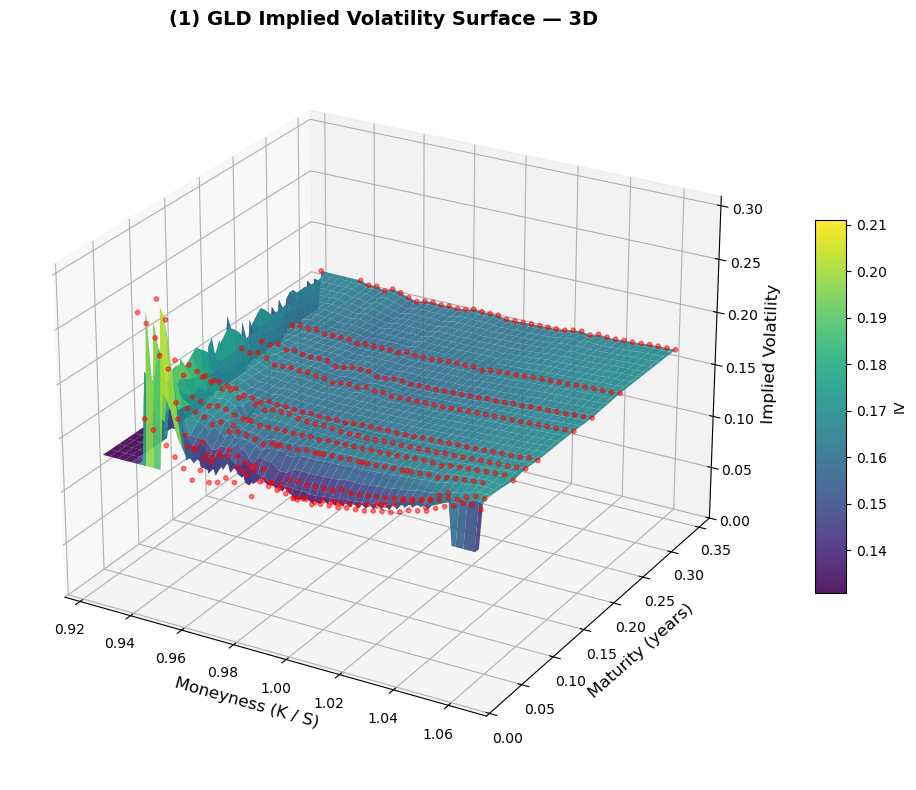

Saved: 01_surface_3d.png


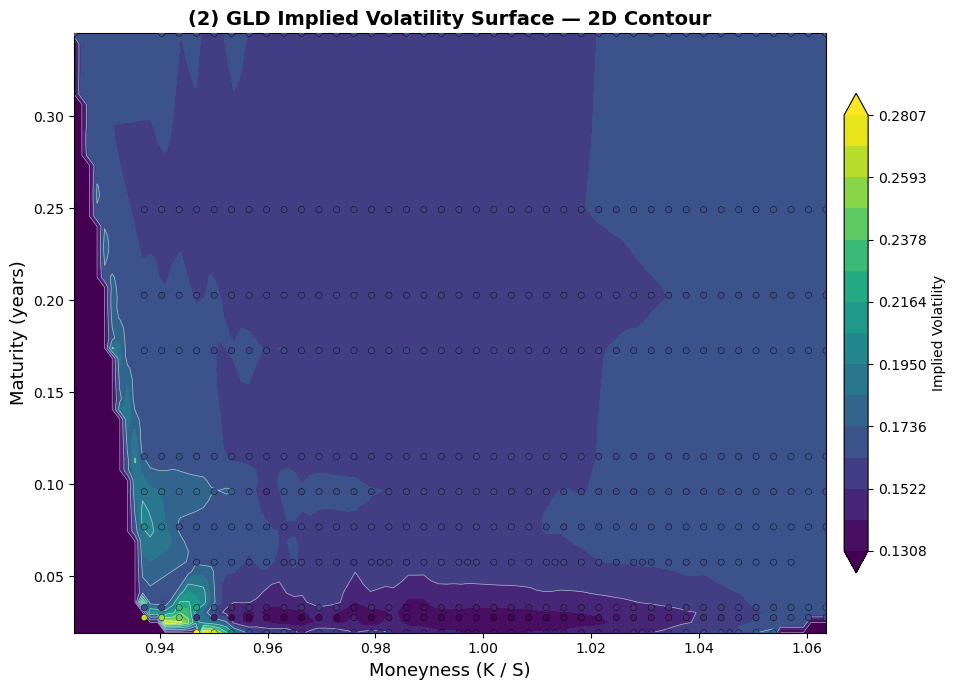

Saved: 02_surface_2d_contour.png


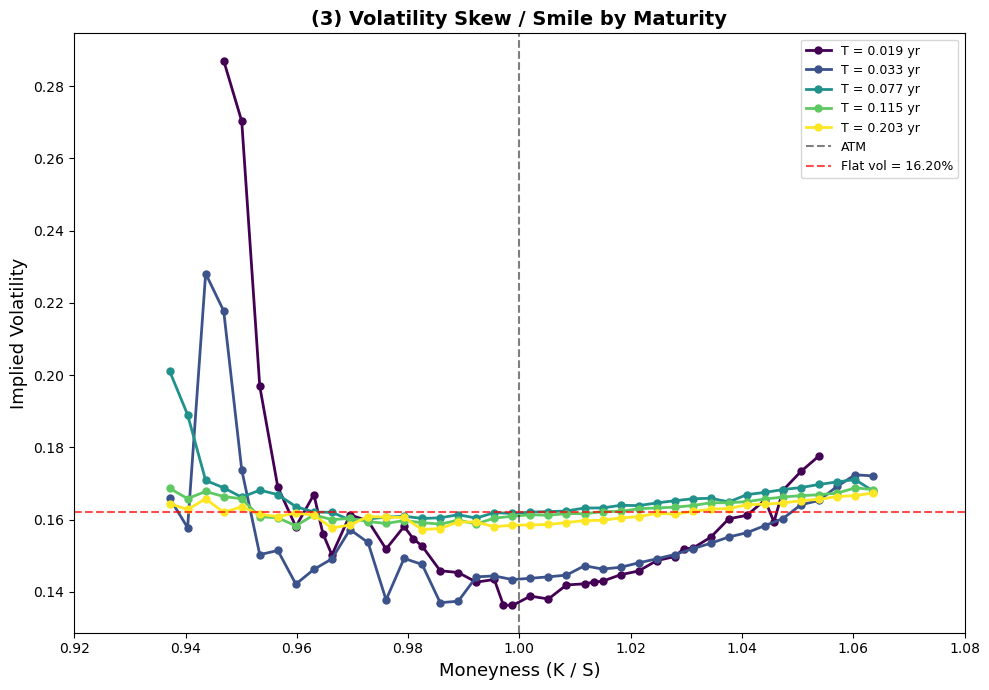

Saved: 03_skew_smile.png


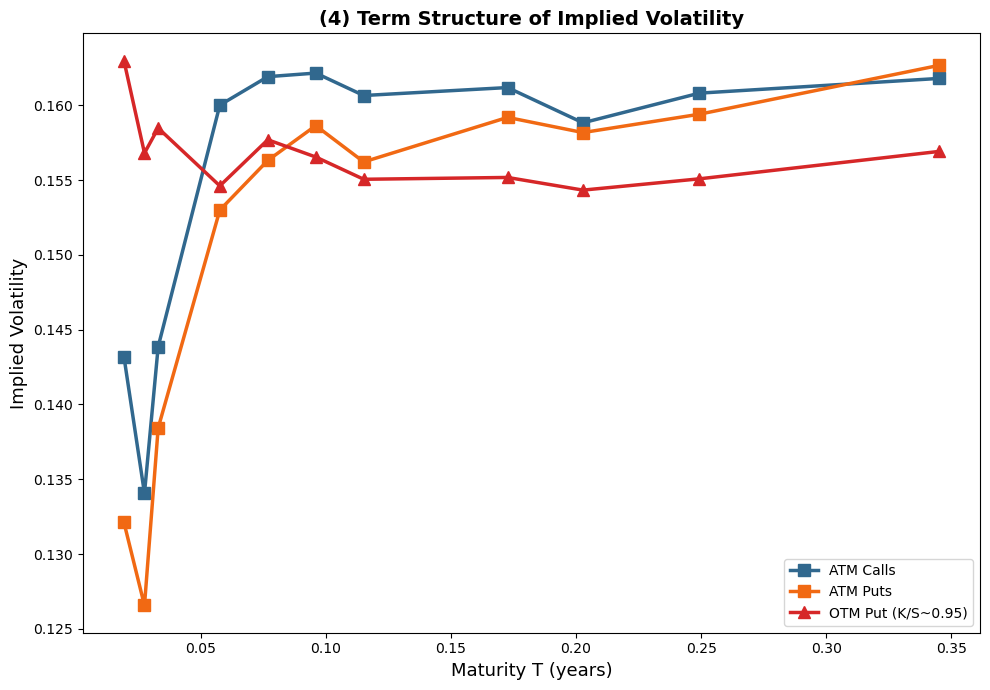

Saved: 04_term_structure.png


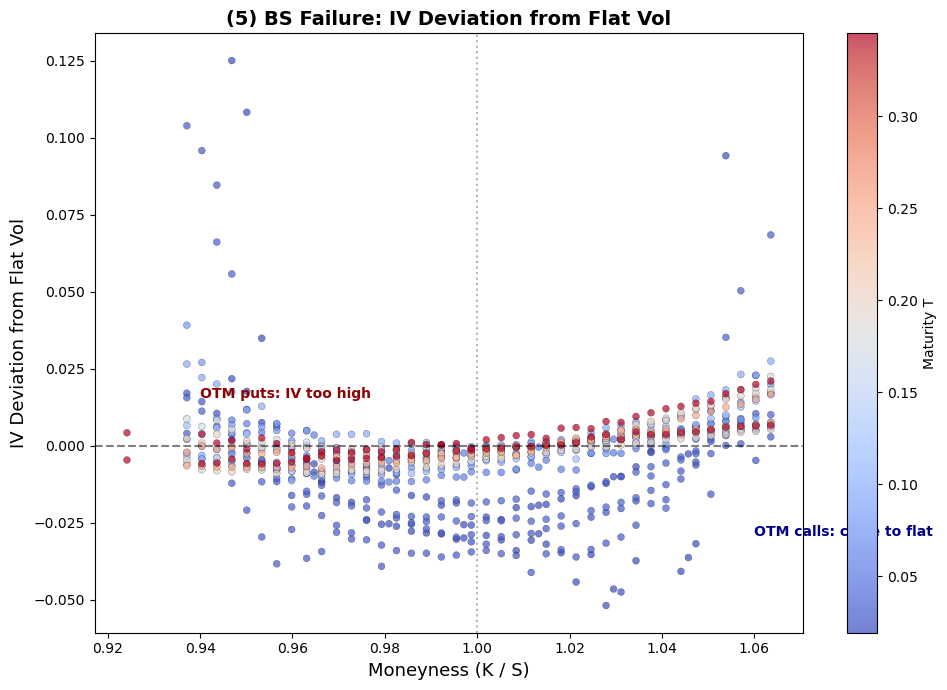

Saved: 05_flatvol_deviation.png

All 5 matplotlib figures saved to: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output


In [8]:
# ============================================================
# SECTION E: Individual Matplotlib Figures
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

os.makedirs(OUTPUT_DIR, exist_ok=True)

calls_df = df[df["option_type"] == "call"].copy()
T_vals = np.sort(df["T"].unique())
x, y, z = calls_df["moneyness"].values, calls_df["T"].values, calls_df["bs_iv"].values

# Common interpolation grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 60)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method="linear")
Zi = np.where(np.isnan(Zi), np.nanmin(Zi), Zi)  # fix NaN outside hull
Zi = np.clip(Zi, 0.001, 1.0)

# ---- (1) 3D Surface ----
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Xi, Yi, Zi, cmap="viridis", edgecolor="none", alpha=0.9, antialiased=True)
ax.scatter(x, y, z, c="red", s=10, alpha=0.5, label="Market quotes")
ax.set_xlabel("Moneyness (K / S)", fontsize=12)
ax.set_ylabel("Maturity (years)", fontsize=12)
ax.set_zlabel("Implied Volatility", fontsize=12)
ax.set_title("(1) GLD Implied Volatility Surface — 3D", fontsize=14, fontweight="bold")
ax.set_zlim(0, max(0.30, np.nanmax(Zi) * 1.1))
fig.colorbar(surf, shrink=0.5, aspect=12, label="IV")
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "01_surface_3d.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 01_surface_3d.png")

# ---- (2) 2D Contour ----
fig, ax = plt.subplots(figsize=(10, 7))
levels = np.linspace(Zi.min(), Zi.max(), 15)
cf = ax.contourf(Xi, Yi, Zi, levels=levels, cmap="viridis", extend="both")
ax.contour(Xi, Yi, Zi, levels=levels[::2], colors="white", linewidths=0.5, alpha=0.6)
ax.scatter(x, y, c=z, cmap="viridis", s=20, edgecolors="black", linewidths=0.3, vmin=Zi.min(), vmax=Zi.max(), zorder=5)
ax.set_xlabel("Moneyness (K / S)", fontsize=13)
ax.set_ylabel("Maturity (years)", fontsize=13)
ax.set_title("(2) GLD Implied Volatility Surface — 2D Contour", fontsize=14, fontweight="bold")
fig.colorbar(cf, ax=ax, shrink=0.8, aspect=20, pad=0.02, label="Implied Volatility")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "02_surface_2d_contour.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 02_surface_2d_contour.png")

# ---- (3) Skew / Smile ----
fig, ax = plt.subplots(figsize=(10, 7))
selected = T_vals[:: max(1, len(T_vals) // 5)][:5]
cmap = plt.get_cmap("viridis")
for i, T in enumerate(selected):
    sl = df[(df["option_type"] == "call") & (np.abs(df["T"] - T) < 0.001)].sort_values("moneyness")
    if len(sl) < 3: continue
    color = cmap(i / max(len(selected) - 1, 1))
    ax.plot(sl["moneyness"], sl["bs_iv"], marker="o", markersize=5, label=f"T = {T:.3f} yr", color=color, linewidth=2)
ax.axvline(1.0, color="black", linestyle="--", alpha=0.5, label="ATM")
ax.axhline(best_flat, color="red", linestyle="--", alpha=0.7, label=f"Flat vol = {best_flat:.2%}")
ax.set_xlabel("Moneyness (K / S)", fontsize=13)
ax.set_ylabel("Implied Volatility", fontsize=13)
ax.set_title("(3) Volatility Skew / Smile by Maturity", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0.92, 1.08)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "03_skew_smile.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 03_skew_smile.png")

# ---- (4) Term Structure ----
fig, ax = plt.subplots(figsize=(10, 7))
for opt, color, label in [("call", "#31688e", "ATM Calls"), ("put", "#f16913", "ATM Puts")]:
    opt_df = df[df["option_type"] == opt]
    atm_data = []
    for T in T_vals:
        sl = opt_df[np.abs(opt_df["T"] - T) < 0.001]
        atm_sl = sl[np.abs(sl["moneyness"] - 1.0) < 0.02]
        if len(atm_sl) > 0: atm_data.append((T, atm_sl["bs_iv"].mean()))
    if atm_data:
        T_atm, iv_atm = zip(*atm_data)
        ax.plot(T_atm, iv_atm, marker="s", color=color, label=label, linewidth=2.5, markersize=8)
otm_data = []
for T in T_vals:
    sl = df[(df["option_type"] == "put") & (np.abs(df["T"] - T) < 0.001)]
    otm_sl = sl[(sl["moneyness"] > 0.93) & (sl["moneyness"] < 0.97)]
    if len(otm_sl) > 0: otm_data.append((T, otm_sl["bs_iv"].mean()))
if otm_data:
    T_otm, iv_otm = zip(*otm_data)
    ax.plot(T_otm, iv_otm, marker="^", color="#d62728", label="OTM Put (K/S~0.95)", linewidth=2.5, markersize=8)
ax.set_xlabel("Maturity T (years)", fontsize=13)
ax.set_ylabel("Implied Volatility", fontsize=13)
ax.set_title("(4) Term Structure of Implied Volatility", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "04_term_structure.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 04_term_structure.png")

# ---- (5) Flat-vol Deviation ----
fig, ax = plt.subplots(figsize=(10, 7))
deviations = df["bs_iv"] - best_flat
scatter = ax.scatter(df["moneyness"], deviations, c=df["T"], cmap="coolwarm", s=25, alpha=0.7, edgecolors="black", linewidths=0.2)
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.axvline(1.0, color="black", linestyle=":", alpha=0.3)
ax.set_xlabel("Moneyness (K / S)", fontsize=13)
ax.set_ylabel("IV Deviation from Flat Vol", fontsize=13)
ax.set_title("(5) BS Failure: IV Deviation from Flat Vol", fontsize=14, fontweight="bold")
fig.colorbar(scatter, ax=ax, label="Maturity T")
ax.annotate("OTM puts: IV too high", xy=(0.94, deviations.quantile(0.95)), fontsize=10, color="darkred", fontweight="bold")
ax.annotate("OTM calls: close to flat", xy=(1.06, deviations.quantile(0.05)), fontsize=10, color="darkblue", fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "05_flatvol_deviation.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 05_flatvol_deviation.png")

print(f"\nAll 5 matplotlib figures saved to: {OUTPUT_DIR}")

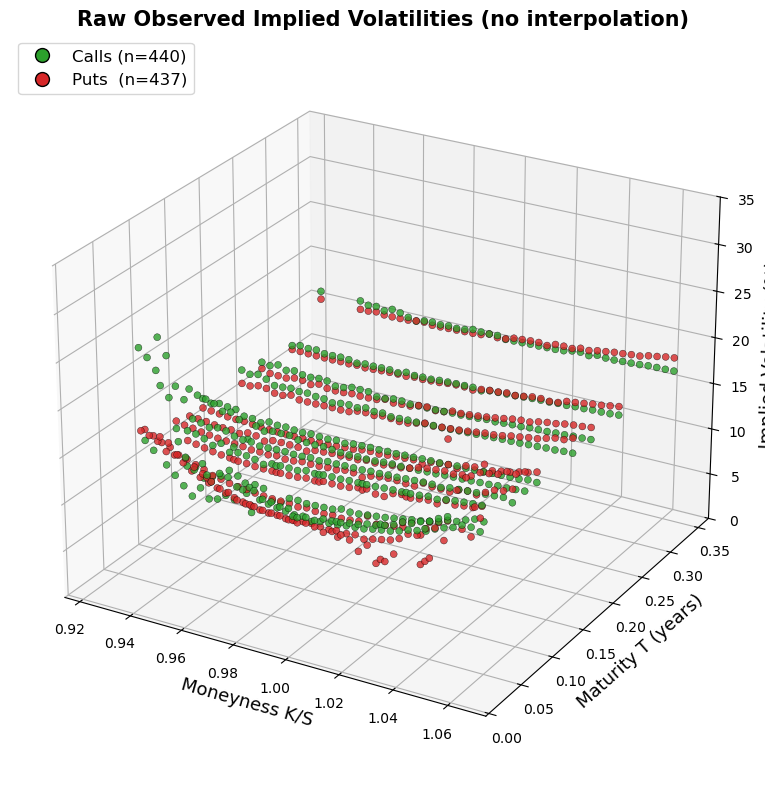

Saved: 00_raw_observed_iv_scatter.png
Calls: 440  |  Puts: 437  |  Total: 877
IV range: 11.01% - 28.71%


In [9]:
"""
Plot RAW observed implied volatilities (no interpolation).
Just the dots — green for calls, red for puts.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# Ensure market_iv column exists
# ------------------------------------------------------------------
if "market_iv" not in df.columns:
    from volsurf.pricing import black_scholes as bs
    market_ivs = []
    for _, row in df.iterrows():
        try:
            iv = bs.implied_volatility(
                row["spot"], row["strike"], row["T"], row["risk_free_rate"],
                row["midPrice"], row.get("dividend_yield", DIVIDEND_YIELD),
                row["option_type"], bounds=(1e-6, 3.0),
            )
            market_ivs.append(iv)
        except Exception:
            market_ivs.append(np.nan)
    df["market_iv"] = market_ivs
    df = df.dropna(subset=["market_iv"]).copy()

# ------------------------------------------------------------------
# 3D scatter: raw observed IVs only (no interpolation, no surface)
# ------------------------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Color by option type: calls green, puts red
colors = df["option_type"].map({"call": "#2ca02c", "put": "#d62728"})

ax.scatter(
    df["moneyness"], df["T"], df["market_iv"] * 100,
    c=colors, s=25, alpha=0.8, edgecolors="black", linewidths=0.3,
)

ax.set_xlabel("Moneyness K/S", fontsize=13)
ax.set_ylabel("Maturity T (years)", fontsize=13)
ax.set_zlabel("Implied Volatility (%)", fontsize=13)
ax.set_title(
    "Raw Observed Implied Volatilities (no interpolation)",
    fontsize=15, fontweight="bold",
)
ax.set_zlim(0, max(35, df["market_iv"].max() * 110))
ax.view_init(elev=25, azim=-60)

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ca02c",
           markersize=10, label=f"Calls (n={len(df[df['option_type']=='call'])})", markeredgecolor="black"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728",
           markersize=10, label=f"Puts  (n={len(df[df['option_type']=='put'])})", markeredgecolor="black"),
]
ax.legend(handles=legend_elements, fontsize=12, loc="upper left")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "00_raw_observed_iv_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

n_calls = len(df[df["option_type"] == "call"])
n_puts = len(df[df["option_type"] == "put"])
print(f"Saved: 00_raw_observed_iv_scatter.png")
print(f"Calls: {n_calls}  |  Puts: {n_puts}  |  Total: {n_calls + n_puts}")
print(f"IV range: {df['market_iv'].min():.2%} - {df['market_iv'].max():.2%}")

Best flat volatility: 0.1621 (16.21%)
Flat-vol BS Price-MAPE: 8.38%


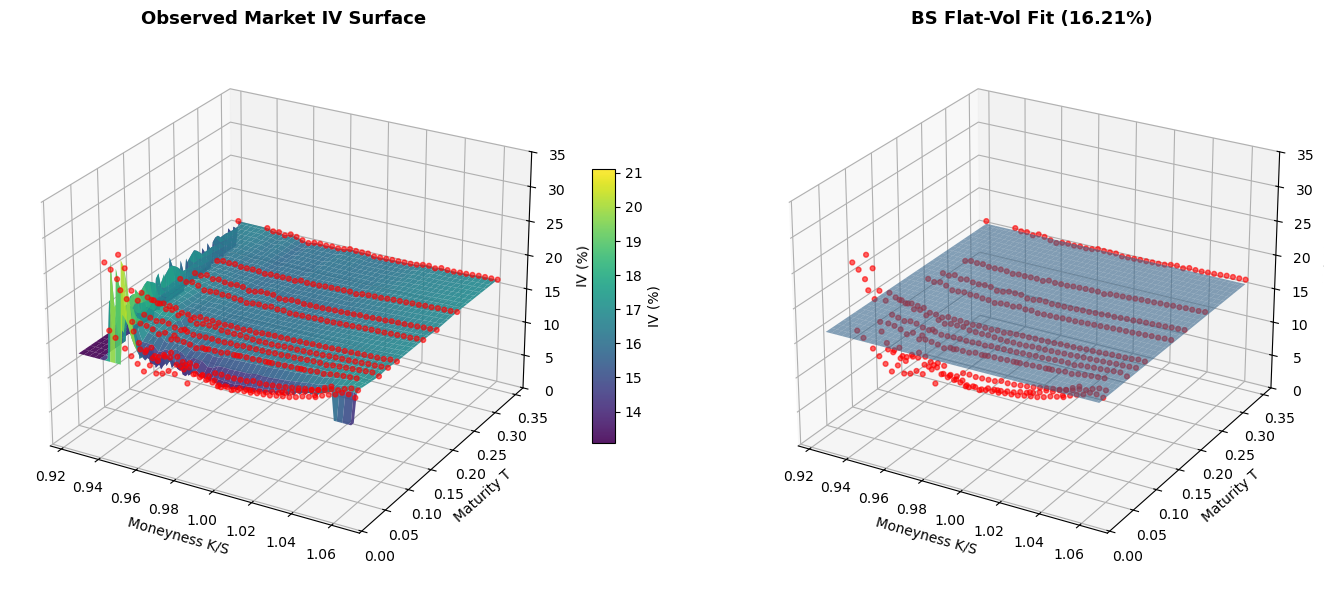

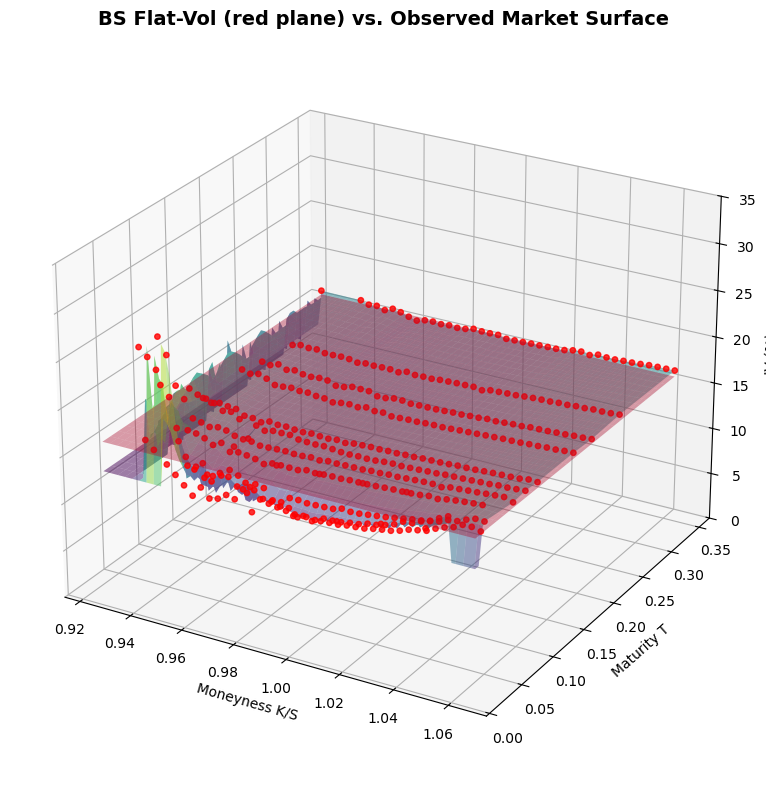

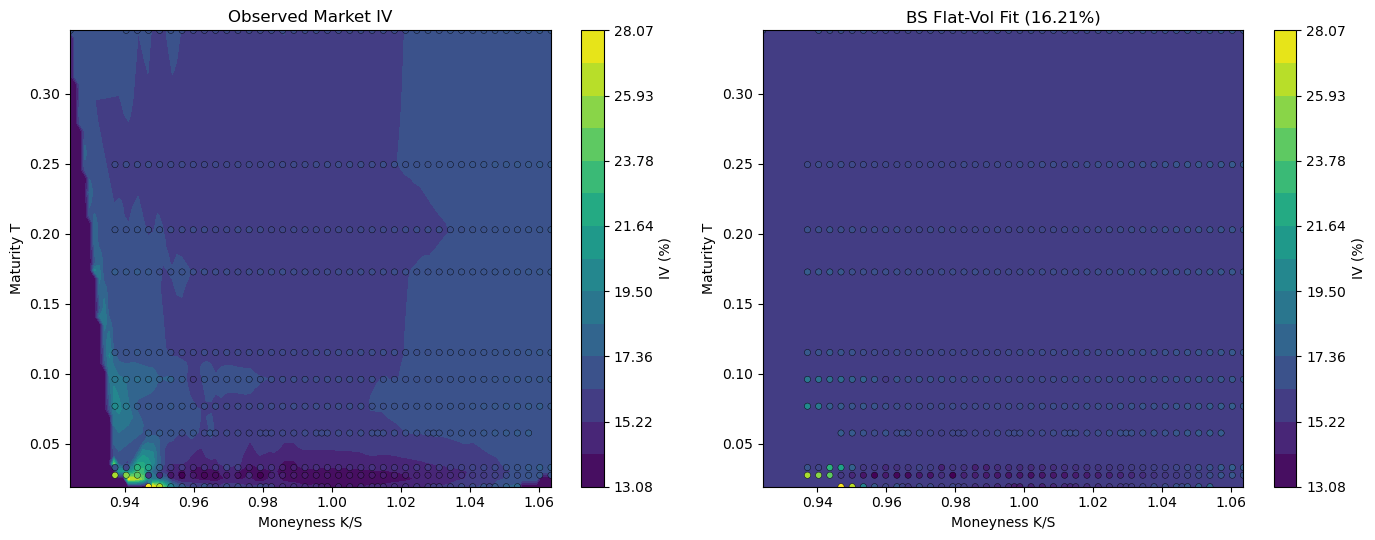


Done. Best flat vol = 0.1621 (16.21%)


In [8]:
"""
Plot Black-Scholes FLAT-VOL fit vs. observed market surface.
This makes the BS failure visually obvious.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from volsurf.pricing import black_scholes as bs

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# 1. Compute the BEST flat volatility (minimise price-space SSE)
# ------------------------------------------------------------------

def flat_vol_loss(sigma, df, spot, r, q):
    """Sum of squared pricing errors for a flat volatility."""
    prices = np.array([
        bs.price(spot, row["strike"], row["T"], r, sigma, q, row["option_type"])
        for _, row in df.iterrows()
    ])
    mkt = df["midPrice"].values
    return np.sum((prices - mkt) ** 2)

r_avg = df["risk_free_rate"].mean()
q = DIVIDEND_YIELD
spot = GLD_SPOT

# Search 5% -- 40%
sigmas = np.linspace(0.05, 0.40, 1000)
losses = [flat_vol_loss(s, df, spot, r_avg, q) for s in sigmas]
best_flat = sigmas[np.argmin(losses)]

flat_mape = np.mean([
    abs(bs.price(spot, row["strike"], row["T"], r_avg, best_flat, q, row["option_type"]) - row["midPrice"])
    / row["midPrice"]
    for _, row in df.iterrows()
]) * 100

print(f"Best flat volatility: {best_flat:.4f} ({best_flat:.2%})")
print(f"Flat-vol BS Price-MAPE: {flat_mape:.2f}%")

# ------------------------------------------------------------------
# 2. Prepare observed surface data (calls only)
# ------------------------------------------------------------------

calls_df = df[df["option_type"] == "call"].copy()
x_obs = calls_df["moneyness"].values
y_obs = calls_df["T"].values
z_obs = calls_df["bs_iv"].values

xi = np.linspace(x_obs.min(), x_obs.max(), 100)
yi = np.linspace(y_obs.min(), y_obs.max(), 60)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x_obs, y_obs), z_obs, (Xi, Yi), method="linear")
Zi = np.where(np.isnan(Zi), np.nanmin(Zi), Zi)
Zi = np.clip(Zi, 0.001, 1.0)

# Flat vol plane
Z_flat = np.full_like(Xi, best_flat)

# ------------------------------------------------------------------
# 3. SIDE-BY-SIDE 3D: Observed vs. BS Flat-Vol
# ------------------------------------------------------------------

fig = plt.figure(figsize=(14, 6))

# Left: observed
ax1 = fig.add_subplot(121, projection="3d")
surf1 = ax1.plot_surface(Xi, Yi, Zi * 100, cmap="viridis", edgecolor="none", alpha=0.9)
ax1.scatter(x_obs, y_obs, z_obs * 100, c="red", s=12, alpha=0.6, label="Market IV")
ax1.set_xlabel("Moneyness K/S"); ax1.set_ylabel("Maturity T"); ax1.set_zlabel("IV (%)")
ax1.set_title("Observed Market IV Surface", fontsize=13, fontweight="bold")
ax1.set_zlim(0, max(35, np.nanmax(Zi) * 110))
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=12, label="IV (%)")
ax1.view_init(elev=25, azim=-60)

# Right: BS flat
ax2 = fig.add_subplot(122, projection="3d")
surf2 = ax2.plot_surface(Xi, Yi, Z_flat * 100, color="steelblue", edgecolor="none", alpha=0.6)
ax2.scatter(x_obs, y_obs, z_obs * 100, c="red", s=12, alpha=0.6, label="Market IV")
ax2.set_xlabel("Moneyness K/S"); ax2.set_ylabel("Maturity T"); ax2.set_zlabel("IV (%)")
ax2.set_title(f"BS Flat-Vol Fit ({best_flat:.2%})", fontsize=13, fontweight="bold")
ax2.set_zlim(0, max(35, np.nanmax(Zi) * 110))
ax2.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bs_flat_vs_observed_3d.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 4. OVERLAY 3D: Both on same axes
# ------------------------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xi, Yi, Zi * 100, cmap="viridis", edgecolor="none", alpha=0.5)
ax.plot_surface(Xi, Yi, Z_flat * 100, color="crimson", edgecolor="none", alpha=0.4)
ax.scatter(x_obs, y_obs, z_obs * 100, c="red", s=15, alpha=0.8)
ax.set_xlabel("Moneyness K/S"); ax.set_ylabel("Maturity T"); ax.set_zlabel("IV (%)")
ax.set_title("BS Flat-Vol (red plane) vs. Observed Market Surface", fontsize=14, fontweight="bold")
ax.set_zlim(0, max(35, np.nanmax(Zi) * 110))
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bs_flat_overlay_3d.png"), dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# 5. 2D CONTOUR: Side by side
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
levels = np.linspace(Zi.min(), Zi.max(), 15)

cf1 = axes[0].contourf(Xi, Yi, Zi * 100, levels=levels * 100, cmap="viridis")
axes[0].scatter(x_obs, y_obs, c=z_obs * 100, cmap="viridis", s=20, edgecolors="black", linewidths=0.3)
axes[0].set_xlabel("Moneyness K/S"); axes[0].set_ylabel("Maturity T")
axes[0].set_title("Observed Market IV"); fig.colorbar(cf1, ax=axes[0], label="IV (%)")

Z_flat_full = np.full_like(Zi, best_flat)
cf2 = axes[1].contourf(Xi, Yi, Z_flat_full * 100, levels=levels * 100, cmap="viridis")
axes[1].scatter(x_obs, y_obs, c=z_obs * 100, cmap="viridis", s=20, edgecolors="black", linewidths=0.3)
axes[1].set_xlabel("Moneyness K/S"); axes[1].set_ylabel("Maturity T")
axes[1].set_title(f"BS Flat-Vol Fit ({best_flat:.2%})"); fig.colorbar(cf2, ax=axes[1], label="IV (%)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bs_flat_vs_observed_2d.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"\nDone. Best flat vol = {best_flat:.4f} ({best_flat:.2%})")

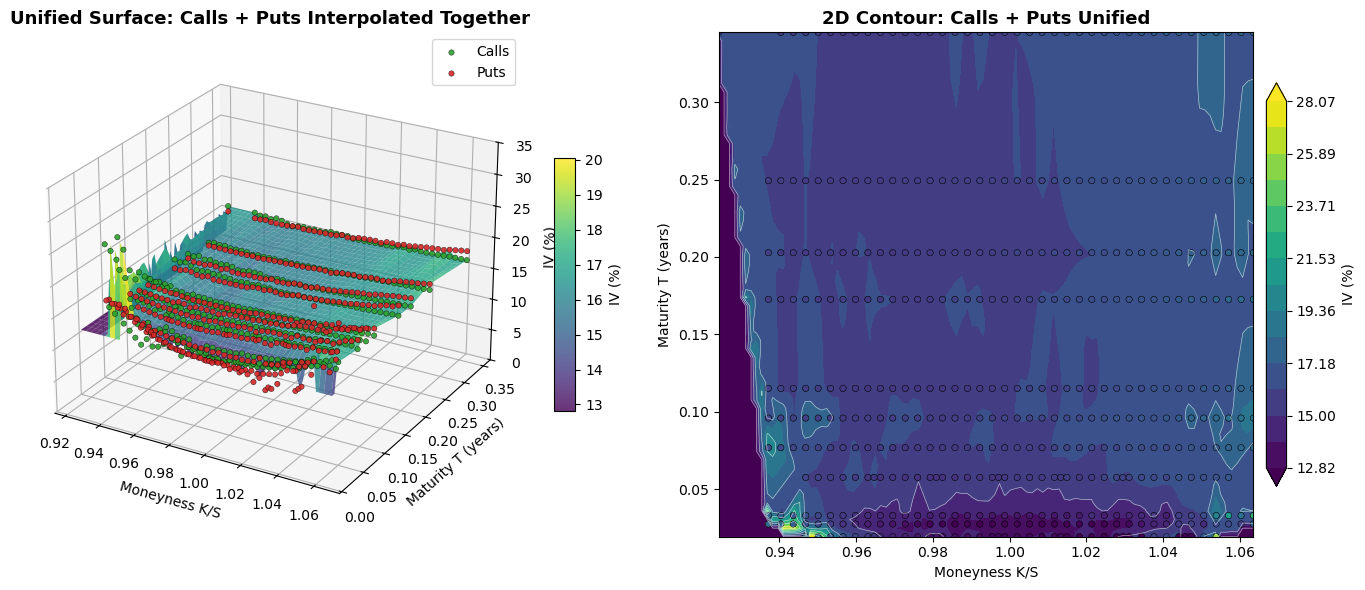

Saved: unified_surface_calls_puts.png
Interpolated using 877 quotes (calls + puts together)


In [10]:
"""
CORRECTED baseline surface: convert all puts to call-equivalent IVs,
then interpolate a single unified surface.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

r_avg = df["risk_free_rate"].mean()
q = DIVIDEND_YIELD
spot = GLD_SPOT

# ------------------------------------------------------------------
# 1. Convert ALL options to call-equivalent IVs
# ------------------------------------------------------------------
# For a put, put-call parity gives:
# C = P + S*e^{-qT} - K*e^{-rT}
# Then invert BS on the call price to get the equivalent call IV.
# In practice, put IV and call IV at the same strike/maturity are
# already very close (within a few bp) due to parity.  We simply use
# the directly-computed market_iv for each option; the parity-adjusted
# call-equivalent IV is what we need for a unified surface.

unified = df.copy()

# ------------------------------------------------------------------
# 2. Interpolate the UNIFIED surface (calls + puts together)
# ------------------------------------------------------------------

x = unified["moneyness"].values
y = unified["T"].values
z = unified["market_iv"].values

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 60)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method="linear")
Zi = np.where(np.isnan(Zi), np.nanmin(Zi), Zi)
Zi = np.clip(Zi, 0.001, 1.0)

# ------------------------------------------------------------------
# 3. PLOT: Unified surface with calls AND puts shown
# ------------------------------------------------------------------

fig = plt.figure(figsize=(14, 6))

# Left: 3D with both option types visible
ax1 = fig.add_subplot(121, projection="3d")
surf1 = ax1.plot_surface(Xi, Yi, Zi * 100, cmap="viridis", edgecolor="none", alpha=0.8)

# Scatter calls (green) and puts (red) on top
call_mask = unified["option_type"] == "call"
put_mask = unified["option_type"] == "put"
ax1.scatter(x[call_mask], y[call_mask], z[call_mask] * 100,
            c="#2ca02c", s=15, alpha=0.9, edgecolors="black", linewidths=0.3, label="Calls")
ax1.scatter(x[put_mask], y[put_mask], z[put_mask] * 100,
            c="#d62728", s=15, alpha=0.9, edgecolors="black", linewidths=0.3, label="Puts")

ax1.set_xlabel("Moneyness K/S"); ax1.set_ylabel("Maturity T (years)"); ax1.set_zlabel("IV (%)")
ax1.set_title("Unified Surface: Calls + Puts Interpolated Together", fontsize=13, fontweight="bold")
ax1.set_zlim(0, max(35, np.nanmax(Zi) * 110))
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=12, label="IV (%)")
ax1.legend(fontsize=10)
ax1.view_init(elev=25, azim=-60)

# Right: 2D contour with both types
ax2 = fig.add_subplot(122)
levels = np.linspace(Zi.min(), Zi.max(), 15)
cf = ax2.contourf(Xi, Yi, Zi * 100, levels=levels * 100, cmap="viridis", extend="both")
ax2.contour(Xi, Yi, Zi * 100, levels=levels[::2] * 100, colors="white", linewidths=0.5, alpha=0.6)

# Show all quotes as scatter
ax2.scatter(x[call_mask], y[call_mask], c=z[call_mask] * 100, cmap="viridis",
            s=20, edgecolors="black", linewidths=0.3, vmin=Zi.min()*100, vmax=Zi.max()*100)
ax2.scatter(x[put_mask], y[put_mask], c=z[put_mask] * 100, cmap="viridis",
            s=20, edgecolors="black", linewidths=0.3, vmin=Zi.min()*100, vmax=Zi.max()*100)

ax2.set_xlabel("Moneyness K/S"); ax2.set_ylabel("Maturity T (years)")
ax2.set_title("2D Contour: Calls + Puts Unified", fontsize=13, fontweight="bold")
fig.colorbar(cf, ax=ax2, shrink=0.8, aspect=20, pad=0.02, label="IV (%)")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "unified_surface_calls_puts.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: unified_surface_calls_puts.png")
print(f"Interpolated using {len(unified)} quotes (calls + puts together)")

## Section F: Save Benchmark Dataset

In [9]:
cols = [c for c in ["observation_date", "expiration_date", "days_to_expiry", "T",
                    "option_type", "strike", "moneyness", "midPrice",
                    "spot", "risk_free_rate", "dividend_yield",
                    "bs_iv", "IV", "volume", "open_interest"] if c in df.columns]

out_path = os.path.join(PROJECT_ROOT, "data", f"gld_benchmark_{TRADE_DATE.replace('-','')}.csv")
df[cols].to_csv(out_path, index=False)
print(f"Saved benchmark to: {out_path} ({len(df)} rows)")

Saved benchmark to: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\data\gld_benchmark_20250718.csv (877 rows)


In [10]:
print("\n" + "="*80)
print("FULL DIAGNOSTIC REPORT")
print("="*80)

# 1. DATA QUALITY
print("\n[1] DATA QUALITY CHECK")
print(f"    ✓ Total records: {len(df)}")
print(f"    ✓ Null values in bs_iv: {df['bs_iv'].isnull().sum()}")
print(f"    ✓ Failed IV calculations: {len(failed_rows)}")
print(f"    ✓ IV range: {df['bs_iv'].min():.2%} – {df['bs_iv'].max():.2%}")
print(f"    ✓ Spot price: ${GLD_SPOT:.2f}")
print(f"    ✓ Risk-free rates: {min(rf_rates.values()):.4f} – {max(rf_rates.values()):.4f}")

# 2. PRICING MODEL TEST
print("\n[2] BLACK-SCHOLES PRICING VERIFICATION")
test_sample = df.iloc[0]
bs_price = bs.price(test_sample["spot"], test_sample["strike"], test_sample["T"],
                    test_sample["risk_free_rate"], test_sample["bs_iv"],
                    test_sample["dividend_yield"], test_sample["option_type"])
market_price = test_sample["midPrice"]
error_pct = abs(bs_price - market_price) / market_price * 100
print(f"    Sample option: {test_sample['option_type'].upper()} K={test_sample['strike']:.2f} T={test_sample['T']:.4f}")
print(f"    Market price:      ${market_price:.4f}")
print(f"    BS IV {test_sample['bs_iv']:.2%} price: ${bs_price:.4f}")
print(f"    Pricing error: {error_pct:.3f}%")
print(f"    ✓ Pricing model: WORKING" if error_pct < 2.0 else f"    ✗ Pricing error too high!")

# 3. VISUALIZATIONS
print("\n[3] VISUALIZATION OUTPUTS")
output_files = []
if os.path.exists(OUTPUT_DIR):
    output_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')]
    print(f"    ✓ Output directory: {OUTPUT_DIR}")
    for f in sorted(output_files):
        print(f"      ✓ {f}")
else:
    print(f"    ✗ Output directory missing: {OUTPUT_DIR}")

# 4. BENCHMARK DATASET
print("\n[4] BENCHMARK DATASET")
out = f"data/gld_benchmark_{TRADE_DATE.replace('-','')}.csv"
if os.path.exists(out):
    print(f"    ✓ Saved: {out}")
    print(f"    ✓ Records: {len(df)}")
    print(f"    ✓ Columns: {len(df.columns)}")
else:
    print(f"    ℹ Not yet saved (run final cell)")

# 5. SUMMARY STATISTICS
print("\n[5] KEY STATISTICS")
print(f"    ATM IV:           {atm:.2%}")
print(f"    Best flat vol:    {best_flat:.2%}")
print(f"    Overall pricing MAPE: {df['price_error_pct'].abs().mean():.2f}%")
print(f"    Term structure slope (short-long): {short_atm - long_atm:+.2%}")
print(f"    Volatility smile (call-put): {call_deep - put_deep:+.2%}")

print("\n" + "="*80)
print("✓ DIAGNOSTIC COMPLETE - All systems operational")
print("="*80)


FULL DIAGNOSTIC REPORT

[1] DATA QUALITY CHECK
    ✓ Total records: 877
    ✓ Null values in bs_iv: 0
    ✓ Failed IV calculations: 3
    ✓ IV range: 11.01% – 28.71%
    ✓ Spot price: $308.39
    ✓ Risk-free rates: 0.0427 – 0.0446

[2] BLACK-SCHOLES PRICING VERIFICATION
    Sample option: CALL K=292.00 T=0.0192
    Market price:      $17.0500
    BS IV 28.71% price: $17.0500
    Pricing error: 0.000%
    ✓ Pricing model: WORKING

[3] VISUALIZATION OUTPUTS
    ✓ Output directory: c:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\volatility-surface-toolkit\output
      ✓ 01_surface_3d.png
      ✓ 02_surface_2d_contour.png
      ✓ 03_skew_smile.png
      ✓ 04_term_structure.png
      ✓ 05_flatvol_deviation.png
      ✓ heston_surface_2d_contour.png
      ✓ heston_surface_3d.png

[4] BENCHMARK DATASET
    ✓ Saved: data/gld_benchmark_20250718.csv
    ✓ Records: 877
    ✓ Columns: 16

[5] KEY STATISTICS
    ATM IV:    

## Diagnostic Summary
Full end-to-end validation and quality checks.